# Setup & Environment Configuration

In [2]:
# Setup & Environment Imports
import sys
from pathlib import Path

# Add project root to sys.path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Structural Break Detection
import ruptures as rpt

# Time Series Forecasting
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

# Formatting Configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'

print(f"Project root resolved to: {PROJECT_ROOT}")

Project root resolved to: C:\Users\JYOTSNA\Documents\fiscal-ledger


# Load Data & Select Focus Nations

In [6]:
# Load dataset and filter for continuous time series
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "global_budgets_clustered.parquet"
df = pd.read_parquet(DATA_PATH)

# Pick 4 diverse countries with strong temporal coverage
FOCUS_COUNTRIES = ['USA', 'Germany', 'UK', 'India']
df_focus = df[df['Country'].isin(FOCUS_COUNTRIES)].sort_values(['Country', 'Year']).copy()

print(f"Focus dataset filtered: {df_focus['Country'].nunique()} countries across years {df_focus['Year'].min()}–{df_focus['Year'].max()}.")

Focus dataset filtered: 4 countries across years 1936–2026.


# Structural Break Detection Function using ruptures (PELT)

In [7]:
# Function to run changepoint detection on a country's series
def detect_structural_breaks(df_country, metric='Defense_Percentage', penalty=3):
    """
    Uses Pruned Exact Linear Time (PELT) algorithm from ruptures 
    to auto-detect structural regime shifts in a spending metric.
    """
    df_sorted = df_country.sort_values('Year').dropna(subset=[metric])
    signal = df_sorted[metric].values
    years = df_sorted['Year'].values
    
    # Cost model: L2 norm (detects mean & variance shifts)
    algo = rpt.Pelt(model="l2", min_size=3).fit(signal)
    break_indices = algo.predict(pen=penalty)
    
    # Map index boundaries back to actual calendar years
    # (ruptures returns boundary indices including the end of series)
    break_years = [years[idx - 1] for idx in break_indices[:-1]]
    
    return df_sorted, break_years

# Test on United States Defense Spending
us_df, us_breaks = detect_structural_breaks(df_focus[df_focus['Country'] == 'USA'], 'Defense_Percentage', penalty=3.5)
print(f"Auto-detected Defense Breakpoint Years for USA: {us_breaks}")

Auto-detected Defense Breakpoint Years for USA: [np.int64(2000), np.int64(2015)]


Multi-Country Changepoint Analysis & Event Mapping

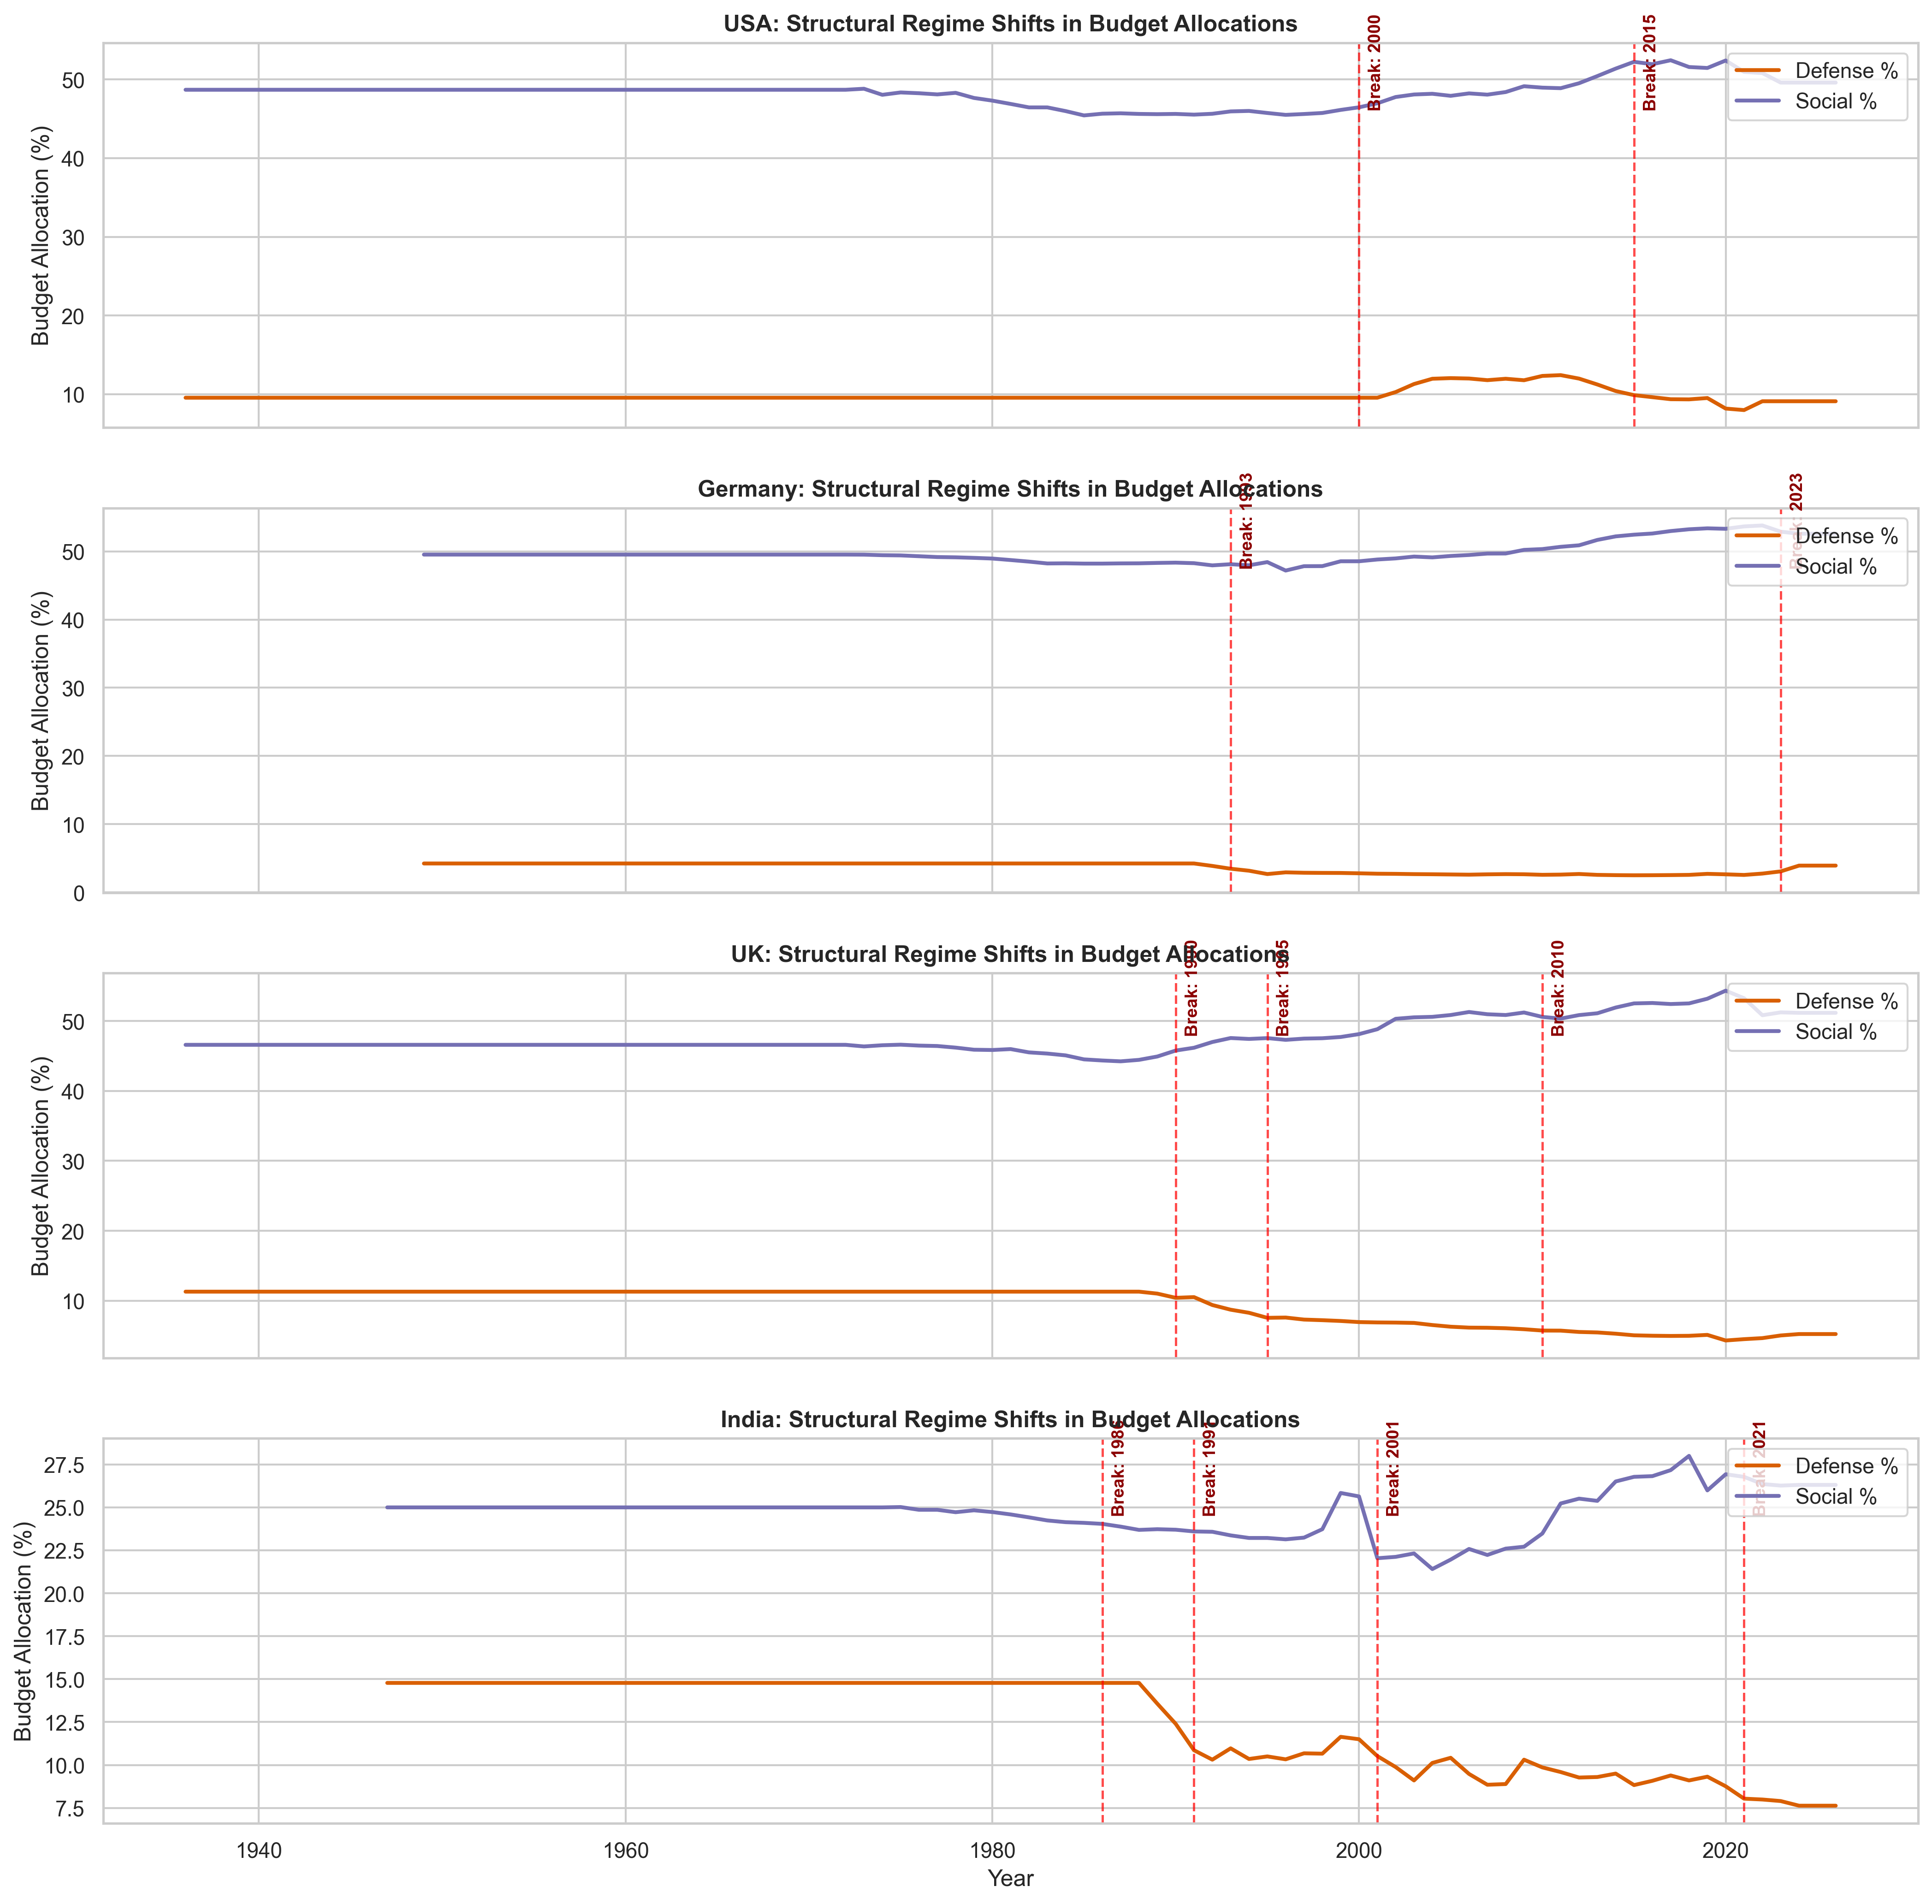

In [8]:
# Plot changepoints for focal countries with historical annotations

# Real-world event reference dictionary for policy validation
HISTORICAL_EVENTS = {
    1945: "End of WWII",
    1950: "Korean War / Cold War Escalation",
    1973: "Oil Crisis & Stagflation",
    1991: "Fall of USSR / Peace Dividend",
    2001: "Post-9/11 Security Shift",
    2008: "Global Financial Crisis"
}

fig, axes = plt.subplots(len(FOCUS_COUNTRIES), 1, figsize=(14, 3.5 * len(FOCUS_COUNTRIES)), sharex=True)

for ax, country in zip(axes, FOCUS_COUNTRIES):
    c_df = df_focus[df_focus['Country'] == country]
    c_df_clean, break_years = detect_structural_breaks(c_df, 'Defense_Percentage', penalty=3.5)
    
    # Plot metric
    ax.plot(c_df_clean['Year'], c_df_clean['Defense_Percentage'], color='#d95f02', linewidth=2, label='Defense %')
    ax.plot(c_df_clean['Year'], c_df_clean['Social_Total_Percentage'], color='#7570b3', linewidth=2, label='Social %')
    
    # Mark detected breakpoints
    for yr in break_years:
        ax.axvline(x=yr, color='red', linestyle='--', alpha=0.7, linewidth=1.2)
        ax.text(yr + 0.5, ax.get_ylim()[1] * 0.85, f"Break: {yr}", color='darkred', fontsize=9, fontweight='bold', rotation=90)
    
    ax.set_title(f"{country}: Structural Regime Shifts in Budget Allocations", fontsize=12, fontweight='bold')
    ax.set_ylabel("Budget Allocation (%)")
    ax.legend(loc='upper right', frameon=True)

plt.xlabel("Year", fontsize=12)
plt.tight_layout()

plt.savefig(PROJECT_ROOT / "outputs" / "05_structural_breaks_detected.png")
plt.show()

# Near-Term Forecasting with SARIMAX ("If Current Trends Hold")

c:\Users\JYOTSNA\Documents\fiscal-ledger\venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


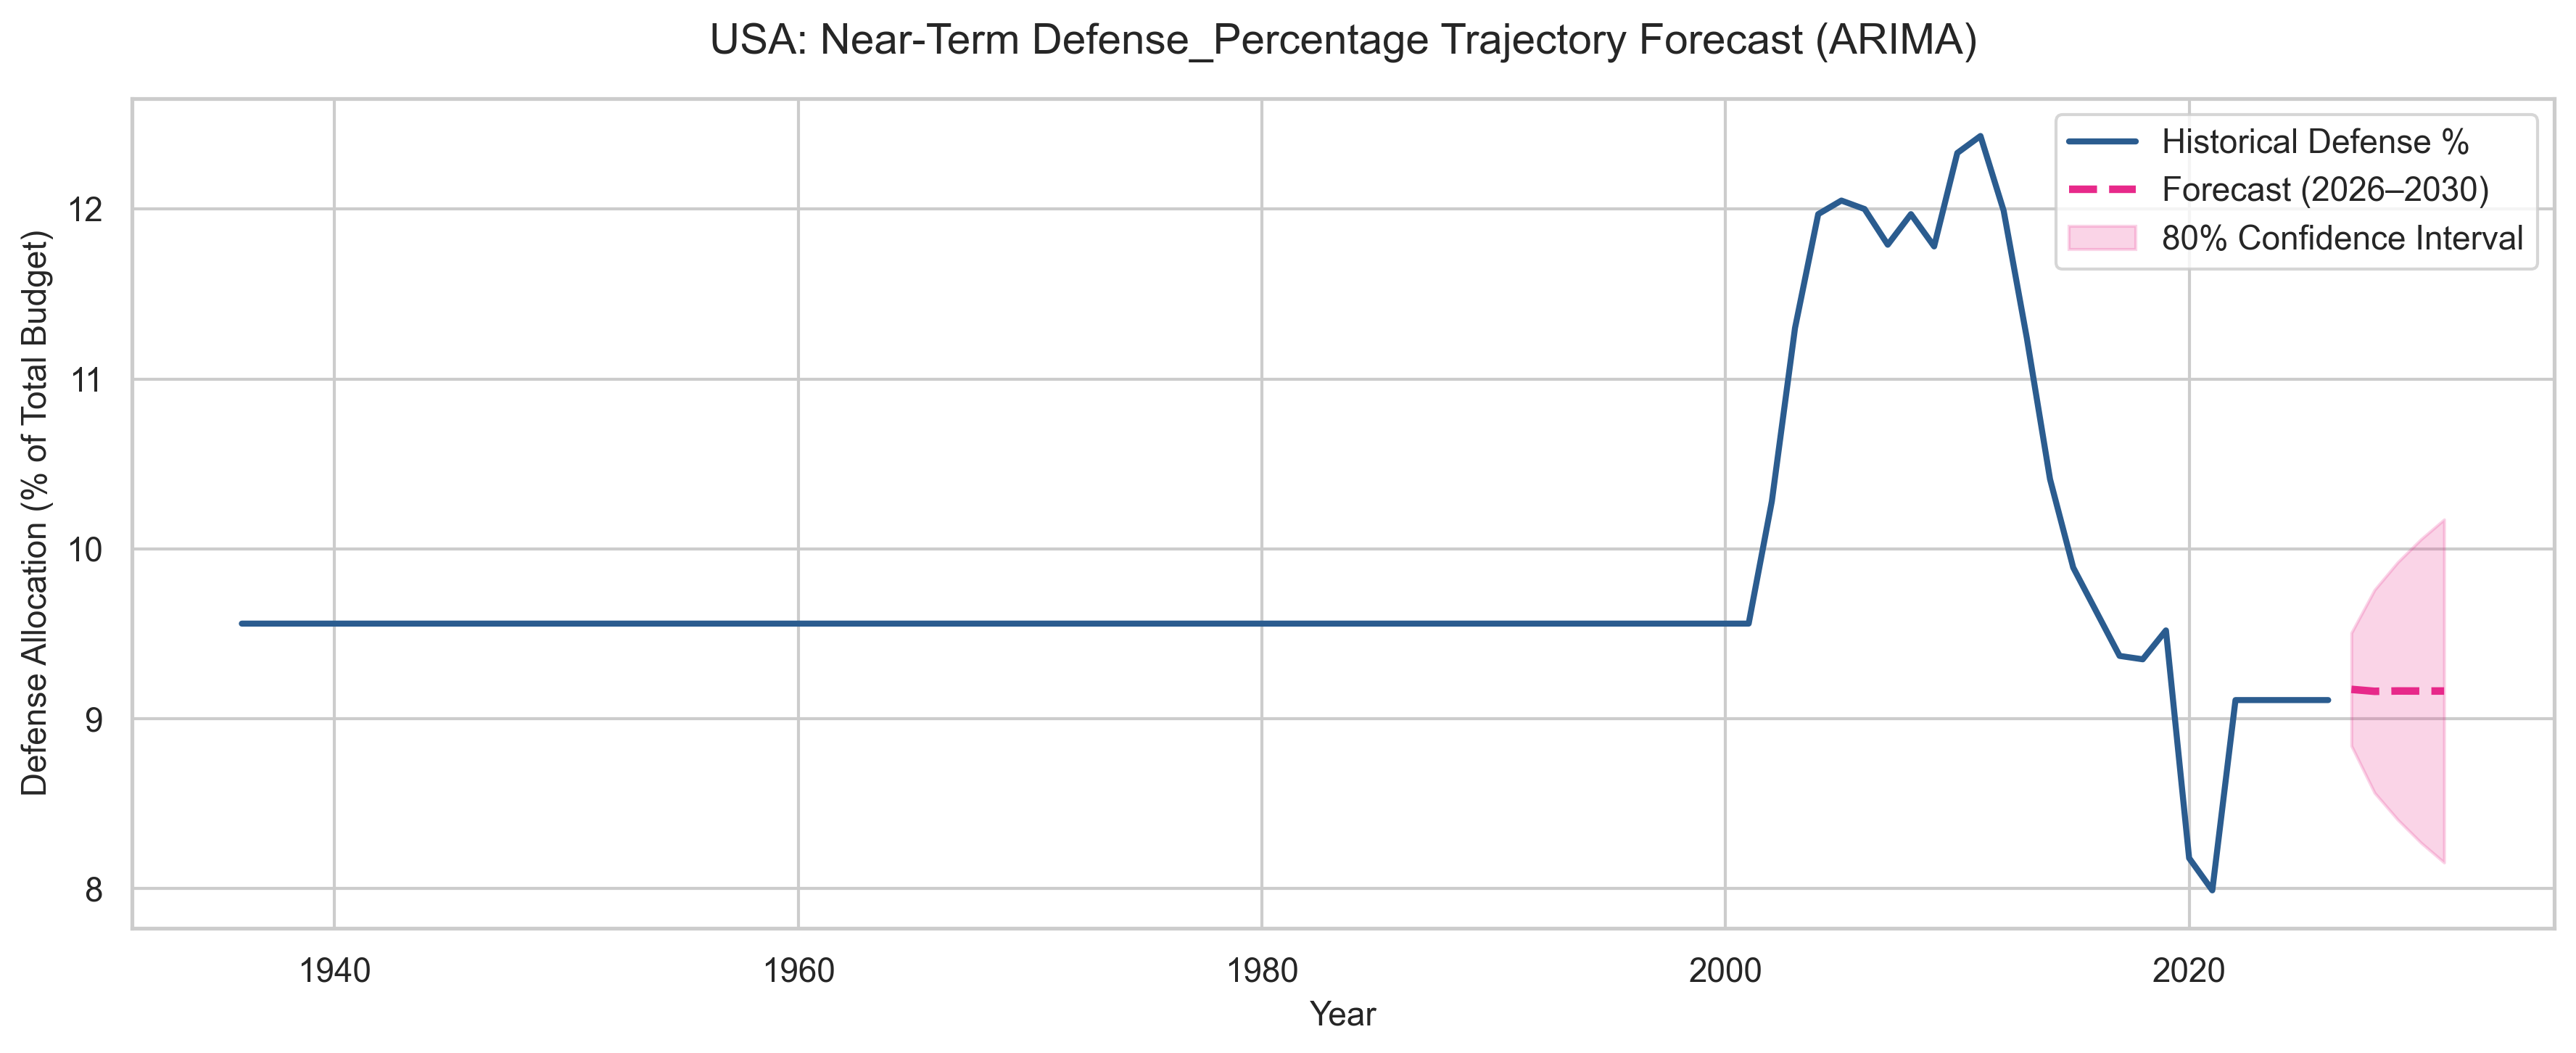

In [9]:
# Short-term forecast (2026–2030) for a selected country using SARIMAX
target_country = 'USA'
target_metric = 'Defense_Percentage'

c_data = df_focus[df_focus['Country'] == target_country].sort_values('Year')
ts_series = pd.Series(c_data[target_metric].values, index=pd.date_range(start=f"{c_data['Year'].min()}-01-01", periods=len(c_data), freq='YS'))

# Fit SARIMAX Model (1,1,1)
model = SARIMAX(ts_series, order=(1, 1, 1), enforce_stationarity=False, enforce_invertibility=False)
results = model.fit(disp=False)

# Forecast next 5 steps (2026–2030)
forecast_steps = 5
forecast_res = results.get_forecast(steps=forecast_steps)
forecast_df = forecast_res.summary_frame(alpha=0.20)  # 80% confidence interval

# Plot Historical + Forecast
plt.figure(figsize=(12, 5))

# Historical
plt.plot(c_data['Year'], c_data[target_metric], color='#2b5c8f', label='Historical Defense %', linewidth=2)

# Forecast
forecast_years = np.arange(c_data['Year'].max() + 1, c_data['Year'].max() + 1 + forecast_steps)
plt.plot(forecast_years, forecast_df['mean'], color='#e7298a', linestyle='--', label='Forecast (2026–2030)', linewidth=2.5)

# Confidence Band
plt.fill_between(
    forecast_years, 
    forecast_df['mean_ci_lower'], 
    forecast_df['mean_ci_upper'], 
    color='#e7298a', 
    alpha=0.2, 
    label='80% Confidence Interval'
)

plt.title(f"{target_country}: Near-Term {target_metric} Trajectory Forecast (ARIMA)", fontsize=14, pad=15)
plt.xlabel("Year", fontsize=11)
plt.ylabel("Defense Allocation (% of Total Budget)", fontsize=11)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()

plt.savefig(PROJECT_ROOT / "outputs" / "05_defense_forecast.png")
plt.show()

# Export Breakpoint & Forecast Metadata

In [10]:
# Save detected changepoints as a reference CSV for the Streamlit dashboard
break_records = []

for c in df['Country'].unique():
    c_subset = df[df['Country'] == c]
    if len(c_subset) >= 10:  # Minimum observations required for changepoint algorithm
        try:
            _, breaks = detect_structural_breaks(c_subset, 'Defense_Percentage', penalty=3.5)
            for b_yr in breaks:
                break_records.append({'Country': c, 'Break_Year': b_yr, 'Metric': 'Defense_Percentage'})
        except Exception:
            continue

df_breaks_all = pd.DataFrame(break_records)
BREAKS_OUTPUT_PATH = PROJECT_ROOT / "data" / "processed" / "detected_structural_breaks.csv"
df_breaks_all.to_csv(BREAKS_OUTPUT_PATH, index=False)

print(f"Auto-detected {len(df_breaks_all)} regime shifts across sovereign nations. Saved to {BREAKS_OUTPUT_PATH}")

Auto-detected 107 regime shifts across sovereign nations. Saved to C:\Users\JYOTSNA\Documents\fiscal-ledger\data\processed\detected_structural_breaks.csv
